In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/home/dascim/repos/histograph/data/output/test_results.csv')

In [3]:
df.tail(40)

,prediction_Term_Healthy,prediction_Term_Sclerotic,prediction_Term_Dead,target_Term_Healthy,target_Term_Sclerotic,target_Term_Dead,glomerulus_index
38,0.632734,0.366558,0.000708,1.0,0.0,0.0,1331186
39,0.055271,0.008761,0.935968,1.0,0.0,0.0,1331212
40,0.781306,0.144803,0.073891,1.0,0.0,0.0,1331238
41,0.061564,0.009807,0.928629,1.0,0.0,0.0,1331329
42,0.700592,0.298365,0.001043,1.0,0.0,0.0,1331368
43,0.815479,0.166175,0.018346,1.0,0.0,0.0,1331472
44,0.808748,0.178137,0.013116,1.0,0.0,0.0,1331602
45,0.693615,0.305255,0.001130,1.0,0.0,0.0,1331615
46,0.352169,0.038091,0.609741,1.0,0.0,0.0,1331628
47,0.800311,0.193452,0.006238,1.0,0.0,0.0,1331719


In [4]:
df['prediction_index'] = df[['prediction_Term_Healthy', 'prediction_Term_Sclerotic', 'prediction_Term_Dead']].idxmax(axis=1)
df['target_index'] = df[['target_Term_Healthy', 'target_Term_Sclerotic', 'target_Term_Dead']].idxmax(axis=1)


In [9]:
df[df['prediction_index'].apply(lambda s:s.split("_")[-1]) != df['target_index'].apply(lambda s:s.split("_")[-1])]

,prediction_Term_Healthy,prediction_Term_Sclerotic,prediction_Term_Dead,target_Term_Healthy,target_Term_Sclerotic,target_Term_Dead,glomerulus_index,prediction_index,target_index,target_class,prediction_class
0,0.068171,0.925234,0.006595,1.0,0.0,0.0,1327650,prediction_Term_Sclerotic,target_Term_Healthy,Healthy,Sclerotic
1,0.493695,0.502802,0.003504,1.0,0.0,0.0,1327689,prediction_Term_Sclerotic,target_Term_Healthy,Healthy,Sclerotic
2,0.000165,0.999578,0.000257,1.0,0.0,0.0,1327923,prediction_Term_Sclerotic,target_Term_Healthy,Healthy,Sclerotic
3,0.453455,0.546222,0.000323,1.0,0.0,0.0,1328144,prediction_Term_Sclerotic,target_Term_Healthy,Healthy,Sclerotic
5,0.459022,0.540769,0.000208,1.0,0.0,0.0,1328365,prediction_Term_Sclerotic,target_Term_Healthy,Healthy,Sclerotic
9,0.077973,0.016373,0.905654,1.0,0.0,0.0,1328755,prediction_Term_Dead,target_Term_Healthy,Healthy,Dead
10,0.052488,0.009880,0.937632,1.0,0.0,0.0,1328846,prediction_Term_Dead,target_Term_Healthy,Healthy,Dead
11,0.049703,0.007245,0.943052,1.0,0.0,0.0,1328859,prediction_Term_Dead,target_Term_Healthy,Healthy,Dead
12,0.098411,0.118041,0.783548,1.0,0.0,0.0,1328989,prediction_Term_Dead,target_Term_Healthy,Healthy,Dead
17,0.152773,0.049062,0.798165,1.0,0.0,0.0,1329327,prediction_Term_Dead,target_Term_Healthy,Healthy,Dead


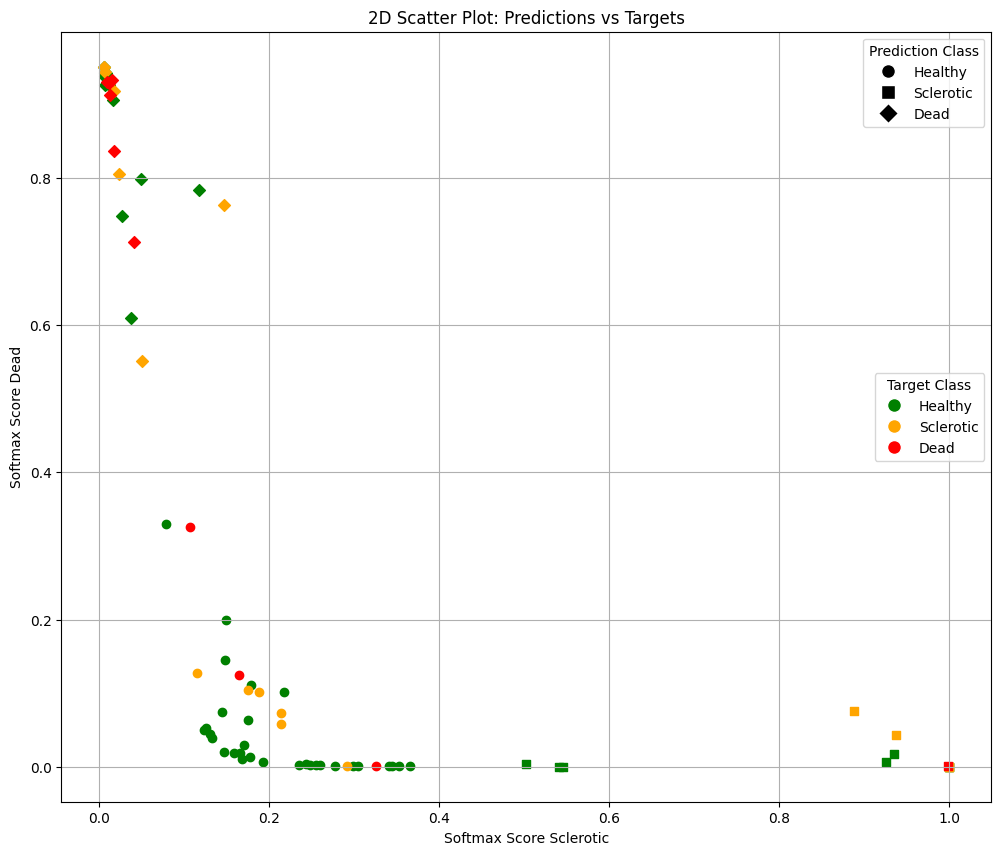

In [7]:
# Map the target and prediction classes to simpler representation
target_map = {'target_Term_Healthy': 'Healthy', 'target_Term_Sclerotic': 'Sclerotic', 'target_Term_Dead': 'Dead'}
prediction_map = {'prediction_Term_Healthy': 'Healthy', 'prediction_Term_Sclerotic': 'Sclerotic', 'prediction_Term_Dead': 'Dead'}

df['target_class'] = df['target_index'].map(target_map)
df['prediction_class'] = df['prediction_index'].map(prediction_map)

# Define markers and colors
markers = {'Healthy': 'o', 'Sclerotic': 's', 'Dead': 'D'}
colors = {'Healthy': 'green', 'Sclerotic': 'orange', 'Dead': 'red'}

plt.figure(figsize=(12, 10))

for i, row in df.iterrows():
    plt.scatter(row['prediction_Term_Sclerotic'], row['prediction_Term_Dead'],
                color=colors[row['target_class']],
                marker=markers[row['prediction_class']],
                label=f"Target: {row['target_class']}, Predicted: {row['prediction_class']}" if i == 0 else "")

# Add axis labels and title
plt.xlabel('Softmax Score Sclerotic')
plt.ylabel('Softmax Score Dead')
plt.title('2D Scatter Plot: Predictions vs Targets')

# Create a custom legend for markers (predicted classes)
handles_markers = [plt.Line2D([0], [0], marker=markers[cls], color='w', markerfacecolor='k', markersize=10, label=cls) for cls in markers]
legend1 = plt.legend(handles=handles_markers, title='Prediction Class', loc='upper right')

# Add the marker legend to the plot
plt.gca().add_artist(legend1)

# Create a custom legend for colors (target classes)
handles_colors = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=cls) for cls, color in colors.items()]
plt.legend(handles=handles_colors, title='Target Class', loc='right')

plt.grid(True)